####Projet ML

##Titre du projet

Prédiction du risque d’addiction au gaming par apprentissage supervisé

Ce projet a pour objectif de prédire le niveau de risque d’addiction au jeu vidéo à partir de données liées aux habitudes de jeu, au sommeil et au mode de vie. Nous utilisons des modèles de machine learning supervisé pour analyser ces relations et comparer leurs performances. L’approche comprend l’analyse des données, le prétraitement, le feature engineering, l’entraînement de plusieurs modèles et leur évaluation, avant un déploiement sous forme d’interface interactive permettant de réaliser des prédictions.

1.Chargement des bibilotheques necessaires

In [6]:
import os
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

In [8]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
DATA_PATH = "Gaming and Mental Health.csv"
TARGET = "gaming_addiction_risk_level"

os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)
os.makedirs("reports/figures", exist_ok=True)

In [9]:
# ============================================================
# 1. CHARGEMENT DES DONNÉES
# ============================================================

df = pd.read_csv("Gaming and Mental Health.csv")


In [10]:
df.head()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [11]:
print("Shape du dataset :", df.shape)
print("\nColonnes :")
print(df.columns.tolist())

Shape du dataset : (1000, 27)

Colonnes :
['record_id', 'age', 'gender', 'daily_gaming_hours', 'game_genre', 'primary_game', 'gaming_platform', 'sleep_hours', 'sleep_quality', 'sleep_disruption_frequency', 'academic_work_performance', 'grades_gpa', 'work_productivity_score', 'mood_state', 'mood_swing_frequency', 'withdrawal_symptoms', 'loss_of_other_interests', 'continued_despite_problems', 'eye_strain', 'back_neck_pain', 'weight_change_kg', 'exercise_hours_weekly', 'social_isolation_score', 'face_to_face_social_hours_weekly', 'monthly_game_spending_usd', 'years_gaming', 'gaming_addiction_risk_level']


In [12]:
print("\nTypes de données :")
print(df.dtypes)


Types de données :
record_id                            object
age                                   int64
gender                               object
daily_gaming_hours                  float64
game_genre                           object
primary_game                         object
gaming_platform                      object
sleep_hours                         float64
sleep_quality                        object
sleep_disruption_frequency           object
academic_work_performance            object
grades_gpa                          float64
work_productivity_score             float64
mood_state                           object
mood_swing_frequency                 object
withdrawal_symptoms                    bool
loss_of_other_interests                bool
continued_despite_problems             bool
eye_strain                             bool
back_neck_pain                         bool
weight_change_kg                    float64
exercise_hours_weekly               float64
social_isola

In [13]:
print("\nValeurs manquantes :")
print(df.isna().sum()[df.isna().sum() > 0])


Valeurs manquantes :
grades_gpa                 246
work_productivity_score    326
dtype: int64


In [14]:
print("\nDoublons :", df.duplicated().sum())


Doublons : 0


In [15]:
# Suppression de la colonne identifiant
df = df.drop(columns=["record_id"], errors="ignore")

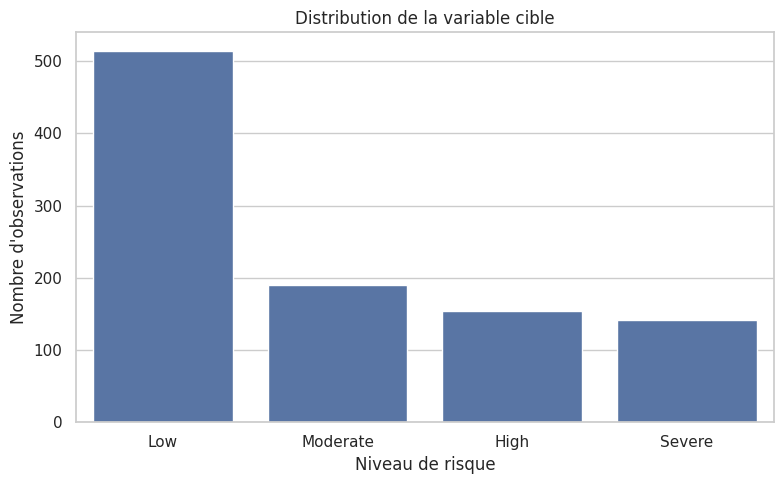

In [16]:
# 2. VISUALISATIONS PERTINENTES
# ============================================================

# Distribution de la cible
plt.figure(figsize=(8, 5))
target_order = df[TARGET].value_counts().index
sns.countplot(data=df, x=TARGET, order=target_order)
plt.title("Distribution de la variable cible")
plt.xlabel("Niveau de risque")
plt.ylabel("Nombre d'observations")
plt.tight_layout()
plt.show()

La distribution de la variable cible montre un déséquilibre marqué entre les classes, avec une majorité d’individus appartenant à la catégorie "Low". Les classes "High" et "Severe", bien que moins représentées, sont particulièrement importantes dans le contexte du problème.

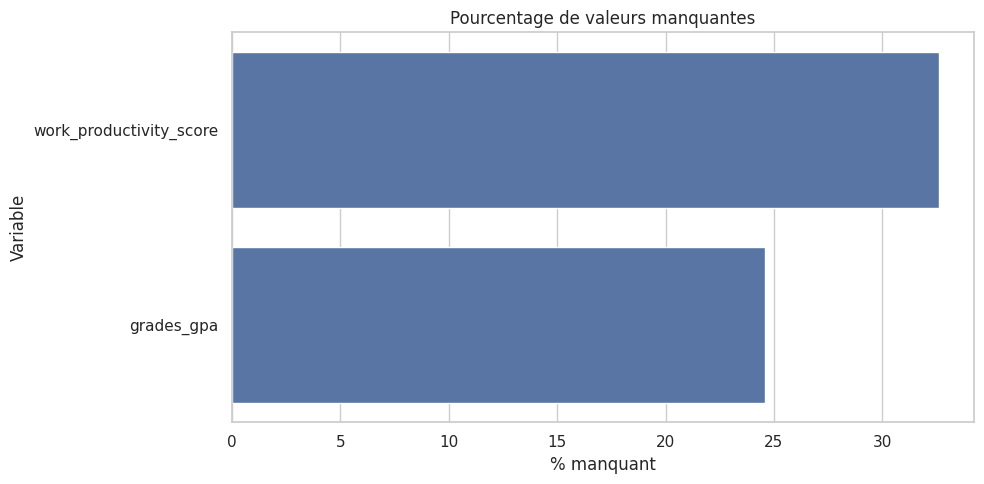

In [17]:
# Valeurs manquantes
missing_df = (
    df.isna().sum()
    .reset_index()
    .rename(columns={"index": "feature", 0: "missing_count"})
)
missing_df["missing_pct"] = missing_df["missing_count"] / len(df) * 100
missing_df = missing_df.sort_values("missing_pct", ascending=False)

if (missing_df["missing_count"] > 0).any():
    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=missing_df[missing_df["missing_count"] > 0],
        x="missing_pct",
        y="feature"
    )
    plt.title("Pourcentage de valeurs manquantes")
    plt.xlabel("% manquant")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.show()


L’analyse des valeurs manquantes révèle que certaines variables, notamment work_productivity_score (32%) et grades_gpa (25%), présentent un taux significatif de données absentes. Ces proportions étant trop élevées pour être ignorées, une stratégie d’imputation a été mise en place afin de conserver ces variables tout en limitant la perte d’information.

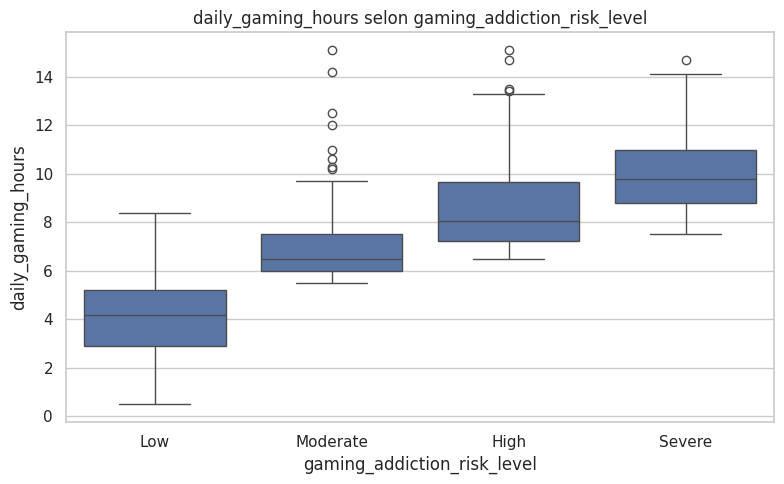

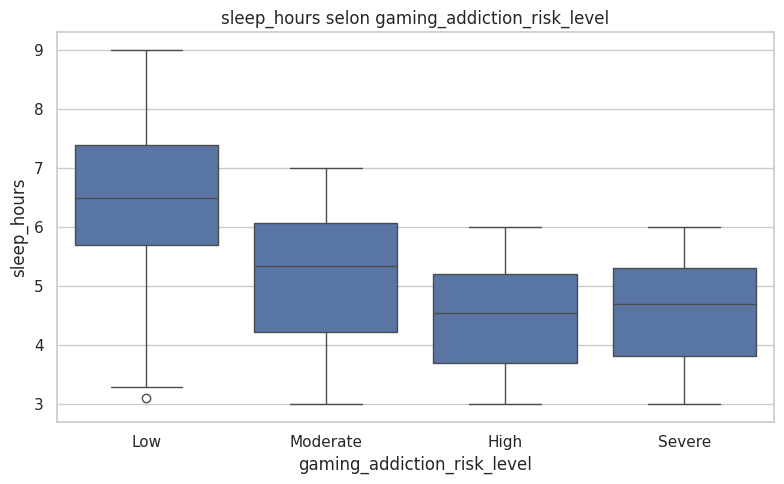

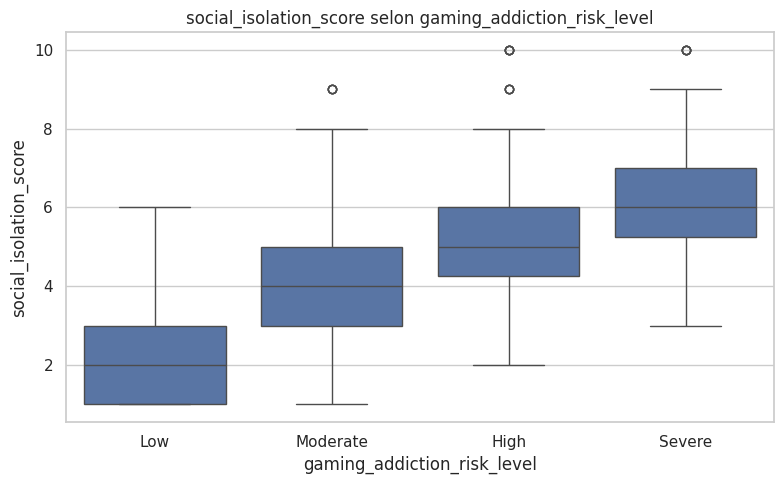

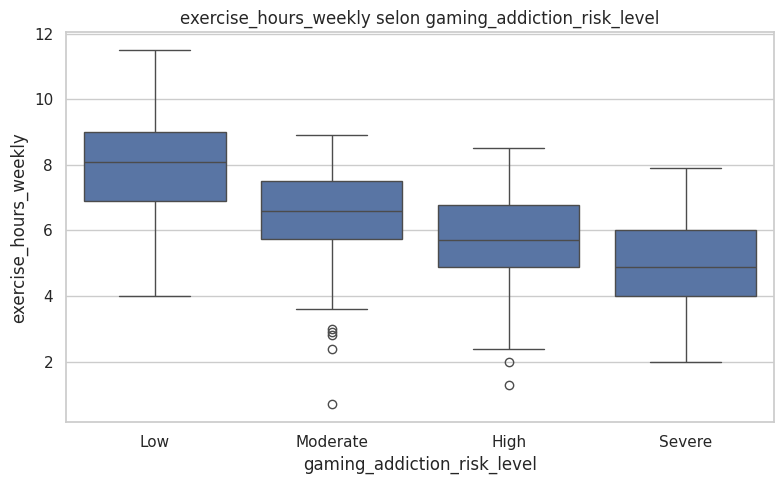

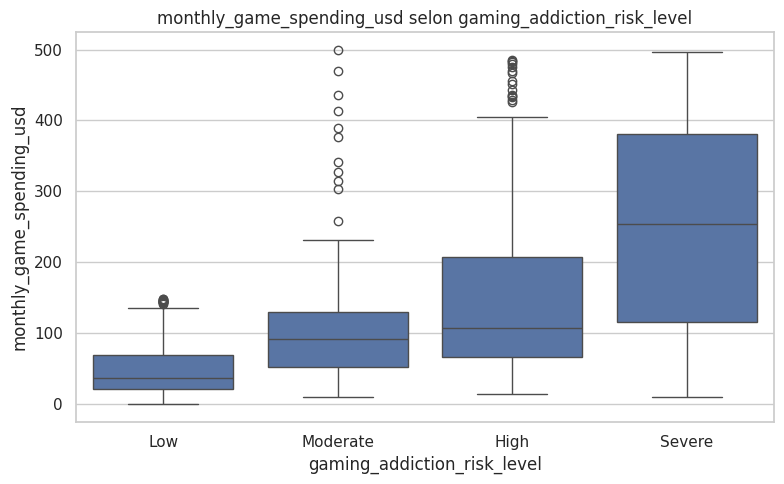

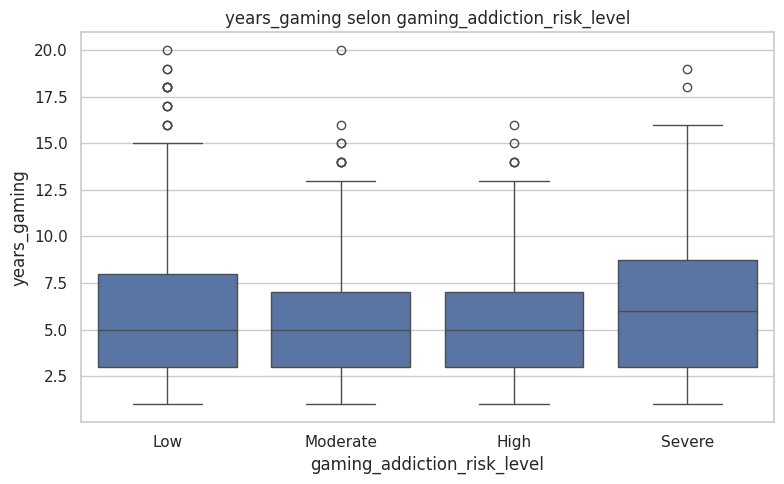

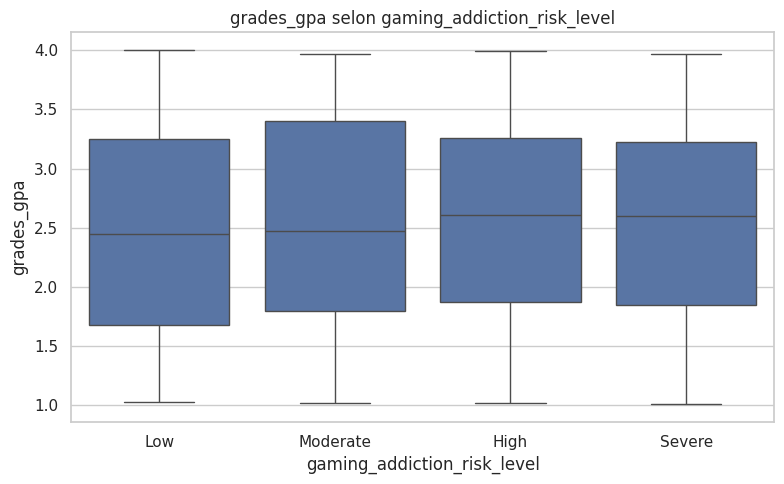

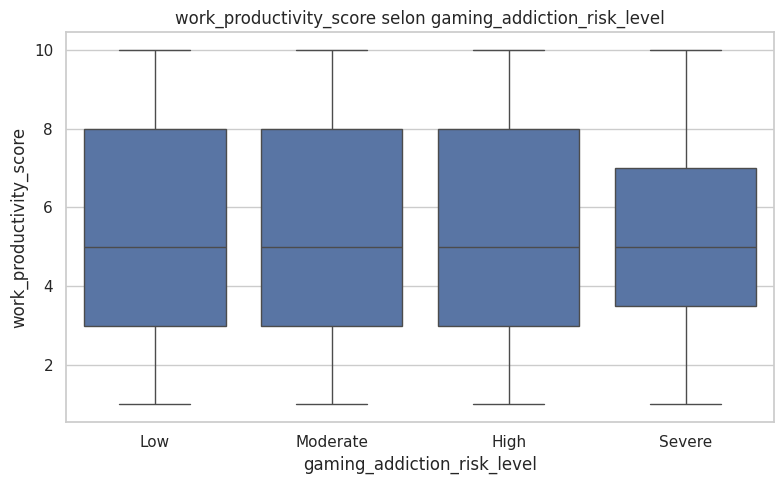

In [18]:
# Boxplots des variables numériques utiles
numeric_cols_to_plot = [
    "daily_gaming_hours",
    "sleep_hours",
    "social_isolation_score",
    "exercise_hours_weekly",
    "monthly_game_spending_usd",
    "years_gaming",
    "grades_gpa",
    "work_productivity_score"
]

for col in numeric_cols_to_plot:
    if col in df.columns:
        plt.figure(figsize=(8, 5))
        sns.boxplot(data=df, x=TARGET, y=col, order=target_order)
        plt.title(f"{col} selon {TARGET}")
        plt.tight_layout()
        plt.show()

L’analyse exploratoire met en évidence des relations claires entre certaines variables et le niveau de risque d’addiction. Le temps de jeu, le nombre d’heures de sommeil et le score d’isolement social apparaissent comme les facteurs les plus discriminants, avec des tendances monotones selon les niveaux de risque. À l’inverse, des variables telles que les résultats académiques ou la productivité présentent peu de variations significatives entre les classes, suggérant un pouvoir prédictif limité.

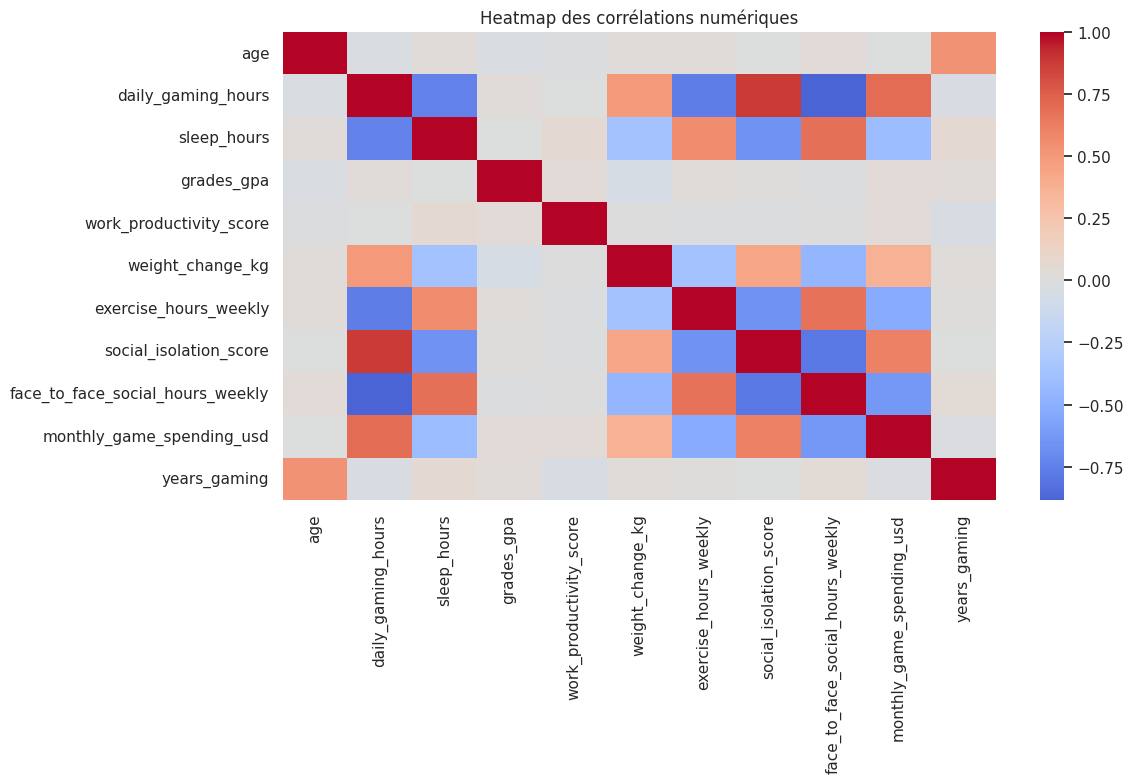

In [19]:
# Heatmap des corrélations numériques
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
if len(numeric_cols) > 1:
    plt.figure(figsize=(12, 8))
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Heatmap des corrélations numériques")
    plt.tight_layout()
    plt.show()

Cette heatmap met en évidence plusieurs relations importantes entre les variables numériques. On observe notamment une corrélation positive forte entre le temps de jeu quotidien (daily_gaming_hours) et le score d’isolement social ainsi que les dépenses mensuelles, indiquant que les joueurs qui jouent davantage ont tendance à être plus isolés et à dépenser plus. À l’inverse, le temps de jeu est négativement corrélé avec le nombre d’heures de sommeil et l’activité physique, ce qui suggère qu’un usage intensif du gaming est associé à un mode de vie moins équilibré. Par ailleurs, certaines variables comme les notes (grades_gpa) ou la productivité présentent des corrélations faibles avec les autres variables, ce qui confirme leur faible pouvoir explicatif. Globalement, ces résultats confirment que le comportement de jeu est étroitement lié à des facteurs de style de vie et constitue un indicateur clé du risque d’addiction.

In [20]:
# Variables catégorielles vs cible
cat_cols_to_plot = [
    "gender",
    "game_genre",
    "gaming_platform",
    "sleep_quality",
    "sleep_disruption_frequency",
    "academic_work_performance",
    "mood_state",
    "mood_swing_frequency"
]

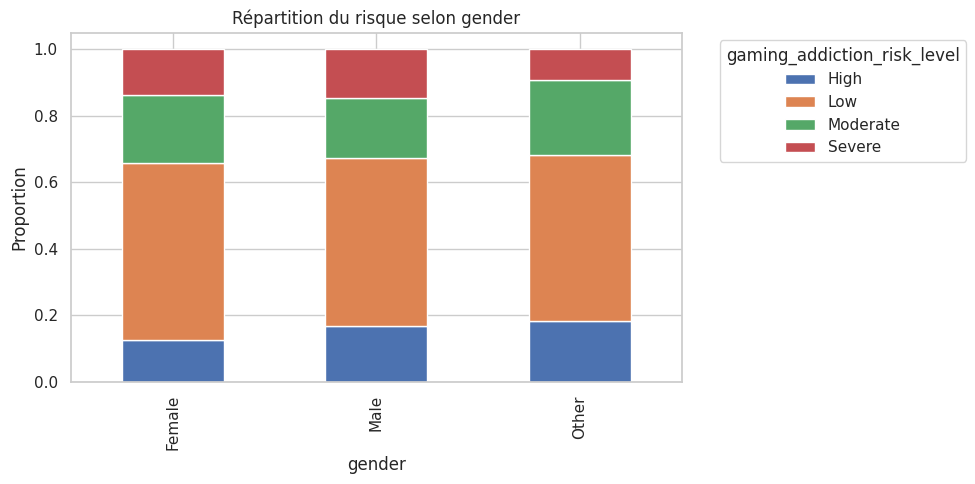

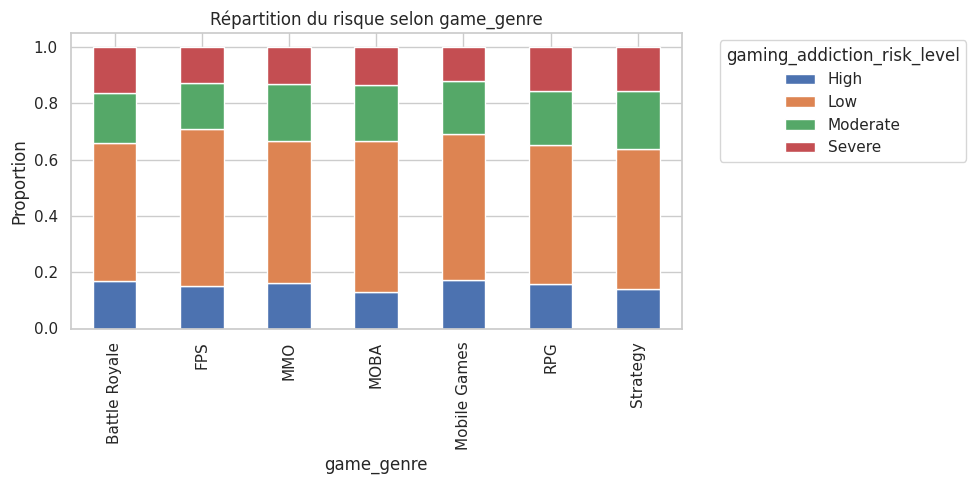

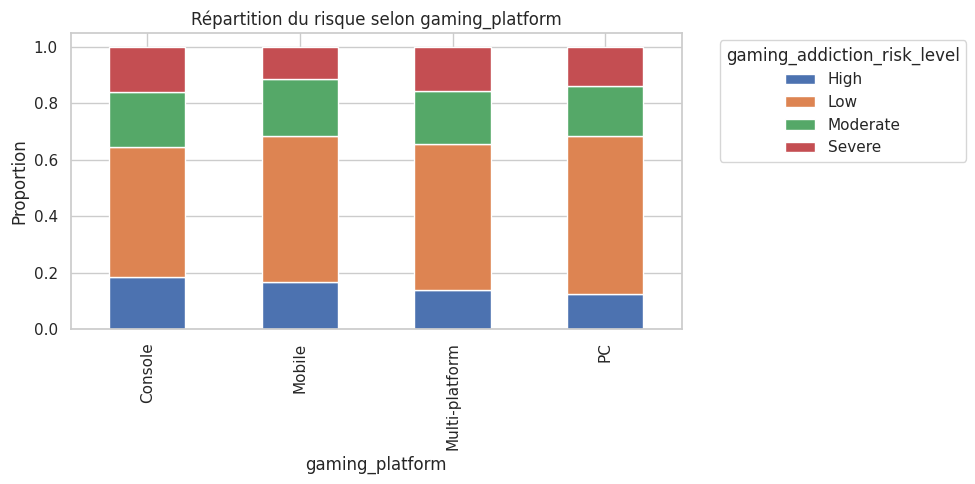

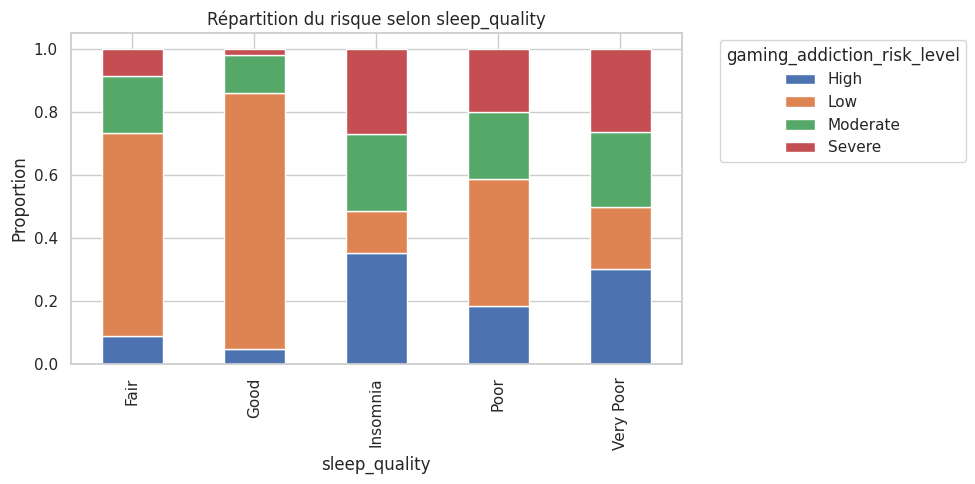

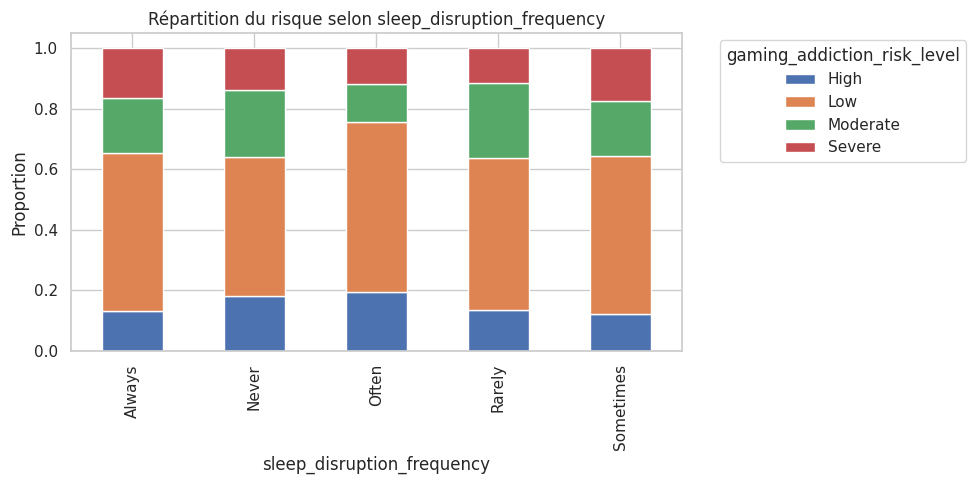

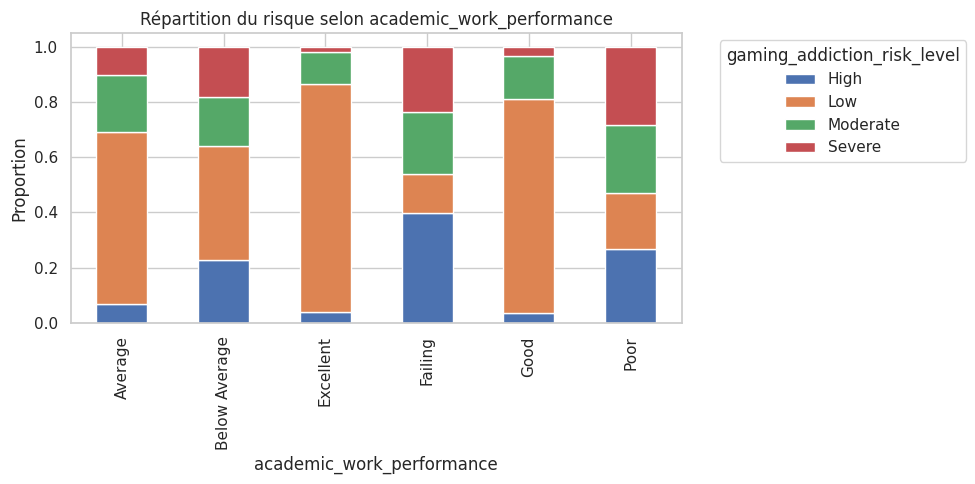

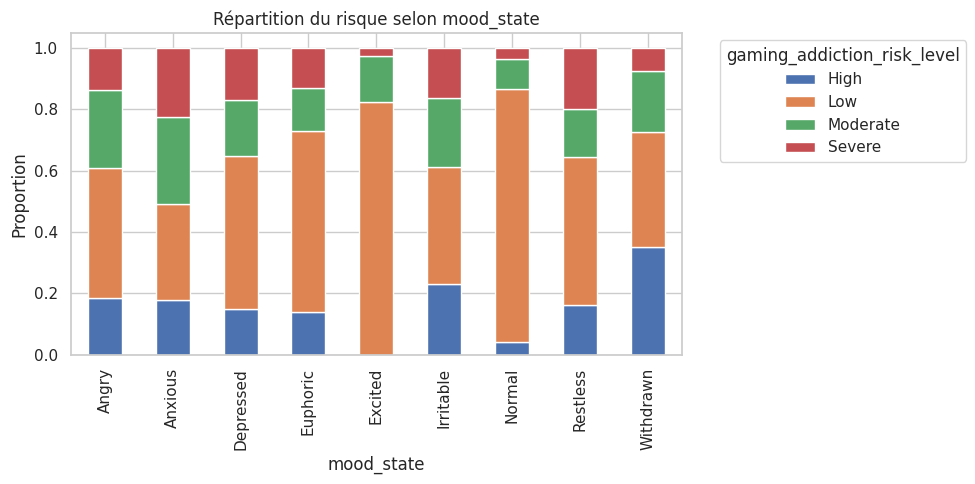

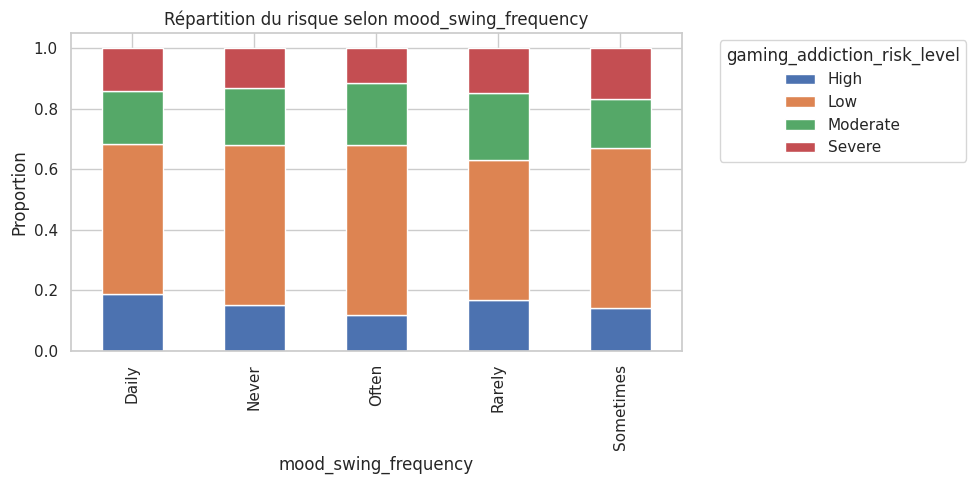

In [21]:
for col in cat_cols_to_plot:
    if col in df.columns:
        prop = pd.crosstab(df[col], df[TARGET], normalize="index")
        prop.plot(kind="bar", stacked=True, figsize=(10, 5))
        plt.title(f"Répartition du risque selon {col}")
        plt.xlabel(col)
        plt.ylabel("Proportion")
        plt.legend(title=TARGET, bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()


Globalement, les variables liées au mode de vie et à la santé (sommeil, état émotionnel, performance) apparaissent plus discriminantes que les variables démographiques ou techniques (genre, plateforme, type de jeu)

In [22]:
# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

def add_features(dataframe: pd.DataFrame) -> pd.DataFrame:
    data = dataframe.copy()

    bool_cols = [
        "withdrawal_symptoms",
        "loss_of_other_interests",
        "continued_despite_problems",
        "eye_strain",
        "back_neck_pain"
    ]

    for col in bool_cols:
        if col in data.columns:
            data[col] = data[col].astype(int)

    if {"age", "years_gaming"}.issubset(data.columns):
        data["gaming_start_age"] = data["age"] - data["years_gaming"]

    if "sleep_hours" in data.columns:
        data["sleep_deficit_hours"] = np.maximum(0, 8 - data["sleep_hours"])

    if {"daily_gaming_hours", "face_to_face_social_hours_weekly"}.issubset(data.columns):
        data["gaming_social_ratio"] = (
            data["daily_gaming_hours"] * 7
        ) / (data["face_to_face_social_hours_weekly"] + 1)

    if {"monthly_game_spending_usd", "daily_gaming_hours"}.issubset(data.columns):
        data["spending_per_hour"] = (
            data["monthly_game_spending_usd"]
        ) / (data["daily_gaming_hours"] + 1)

    if {"withdrawal_symptoms", "loss_of_other_interests", "continued_despite_problems"}.issubset(data.columns):
        data["behavioral_risk_score"] = (
            data["withdrawal_symptoms"]
            + data["loss_of_other_interests"]
            + data["continued_despite_problems"]
        )

    if {"eye_strain", "back_neck_pain"}.issubset(data.columns):
        data["physical_symptom_score"] = (
            data["eye_strain"] + data["back_neck_pain"]
        )

    if {"exercise_hours_weekly", "social_isolation_score"}.issubset(data.columns):
        data["exercise_isolation_ratio"] = (
            data["exercise_hours_weekly"] + 1
        ) / (data["social_isolation_score"] + 1)

    return data


df = add_features(df)


In [23]:
print("\nShape après feature engineering :", df.shape)


Shape après feature engineering : (1000, 33)


L'étape de feature engineering a été réalisée afin de créer de nouvelles variables pertinentes à partir des données existantes, notamment en combinant des indicateurs liés au comportement de jeu, au sommeil et au mode de vie. Ces transformations visent à mieux capturer les relations complexes entre les variables et à améliorer la capacité prédictive des modèle

In [24]:
# ============================================================
# 4. SÉPARATION FEATURES / CIBLE
# ============================================================

X = df.drop(columns=[TARGET])
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

In [25]:
print("\nTrain shape :", X_train.shape)
print("Test shape :", X_test.shape)



Train shape : (800, 32)
Test shape : (200, 32)


In [26]:
print("\nDistribution y_train :")
print(y_train.value_counts(normalize=True).round(3))



Distribution y_train :
gaming_addiction_risk_level
Low         0.514
Moderate    0.190
High        0.154
Severe      0.142
Name: proportion, dtype: float64


In [27]:
print("\nDistribution y_test :")
print(y_test.value_counts(normalize=True).round(3))


Distribution y_test :
gaming_addiction_risk_level
Low         0.515
Moderate    0.190
High        0.155
Severe      0.140
Name: proportion, dtype: float64


In [28]:
# ============================================================
# 5. PRÉTRAITEMENT
# ============================================================

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()


In [29]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [30]:
# ============================================================
# 6. MODÈLES SUPERVISÉS À TESTER
# ============================================================

models = {
    "logistic_regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "decision_tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "random_forest": RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "gradient_boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}


Les métriques telles que le Macro-F1, la précision macro, le rappel macro et la balanced accuracy ont été utilisées afin de prendre en compte le déséquilibre entre les classes et d’évaluer de manière équitable les performances du modèle sur chaque niveau de risque, plutôt que de se limiter à une accuracy globale potentiellement trompeuse

In [31]:
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro"
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [32]:
# ============================================================
# 7. CROSS-VALIDATION
# ============================================================

cv_results_list = []

for model_name, model in models.items():
    print(f"\n===== Cross-validation : {model_name} =====")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    row = {
        "model": model_name,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
        "cv_f1_macro_mean": scores["test_f1_macro"].mean(),
        "cv_precision_macro_mean": scores["test_precision_macro"].mean(),
        "cv_recall_macro_mean": scores["test_recall_macro"].mean(),
        "cv_accuracy_std": scores["test_accuracy"].std(),
        "cv_f1_macro_std": scores["test_f1_macro"].std()
    }
    cv_results_list.append(row)


===== Cross-validation : logistic_regression =====

===== Cross-validation : decision_tree =====

===== Cross-validation : random_forest =====

===== Cross-validation : gradient_boosting =====


In [33]:
cv_results_df = pd.DataFrame(cv_results_list).sort_values("cv_f1_macro_mean", ascending=False)
print("\nRésultats CV :")
print(cv_results_df)



Résultats CV :
                 model  cv_accuracy_mean  cv_balanced_accuracy_mean  \
1        decision_tree           0.99500                   0.995030   
3    gradient_boosting           0.99500                   0.995030   
2        random_forest           0.98000                   0.970044   
0  logistic_regression           0.95875                   0.938211   

   cv_f1_macro_mean  cv_precision_macro_mean  cv_recall_macro_mean  \
1          0.994765                 0.994717              0.995030   
3          0.994765                 0.994717              0.995030   
2          0.969489                 0.969551              0.970044   
0          0.937508                 0.937970              0.938211   

   cv_accuracy_std  cv_f1_macro_std  
1         0.004677         0.004615  
3         0.004677         0.004615  
2         0.012119         0.019115  
0         0.017048         0.026829  


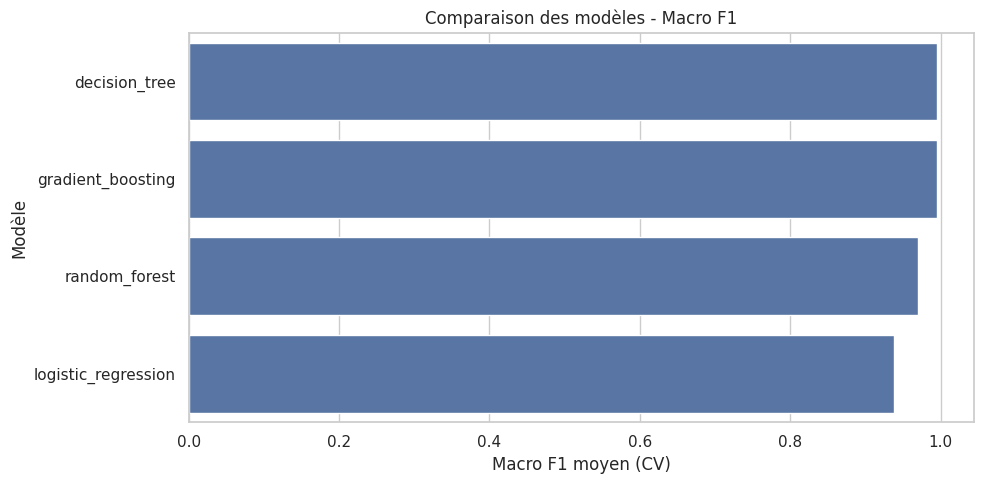

In [34]:
# Graphe comparaison Macro-F1
plt.figure(figsize=(10, 5))
sns.barplot(data=cv_results_df, x="cv_f1_macro_mean", y="model")
plt.title("Comparaison des modèles - Macro F1")
plt.xlabel("Macro F1 moyen (CV)")
plt.ylabel("Modèle")
plt.tight_layout()
plt.show()

Les scores très élevés et proches entre les modèles suggèrent que le problème est relativement simple à apprendre, ce qui peut indiquer une forte corrélation entre les variables explicatives et la cible. Cela peut également refléter un risque de redondance d’information ou un dataset structuré de manière très cohérente.

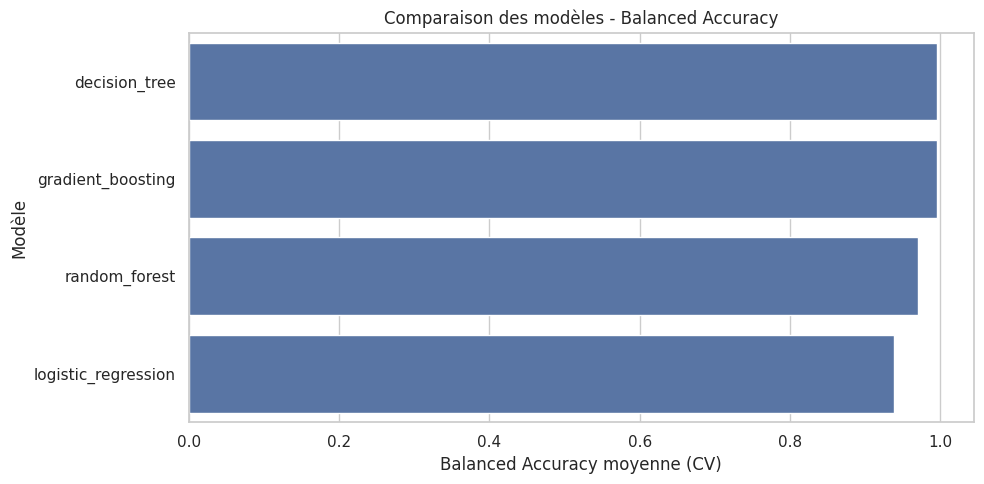

In [35]:
# Graphe comparaison Balanced Accuracy
plt.figure(figsize=(10, 5))
sns.barplot(data=cv_results_df, x="cv_balanced_accuracy_mean", y="model")
plt.title("Comparaison des modèles - Balanced Accuracy")
plt.xlabel("Balanced Accuracy moyenne (CV)")
plt.ylabel("Modèle")
plt.tight_layout()
plt.show()

In [36]:
# ============================================================
# 8. ENTRAÎNEMENT FINAL + ÉVALUATION TEST
# ============================================================

test_results_list = {}
trained_pipelines = {}

In [37]:
for model_name, model in models.items():
    print(f"\n########## TRAIN FINAL : {model_name} ##########")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    trained_pipelines[model_name] = pipeline

    y_pred = pipeline.predict(X_test)

    metrics_dict = {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "precision_macro": precision_score(y_test, y_pred, average="macro"),
        "recall_macro": recall_score(y_test, y_pred, average="macro")
    }

    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)
        classes = pipeline.named_steps["model"].classes_
        y_test_bin = label_binarize(y_test, classes=classes)

        try:
            metrics_dict["roc_auc_macro_ovr"] = roc_auc_score(
                y_test_bin,
                y_proba,
                multi_class="ovr",
                average="macro"
            )
        except Exception:
            metrics_dict["roc_auc_macro_ovr"] = None
    else:
        metrics_dict["roc_auc_macro_ovr"] = None

    test_results_list[model_name] = metrics_dict

    print("\nClassification report :")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=sorted(y.unique()),
        yticklabels=sorted(y.unique())
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Classe prédite")
    plt.ylabel("Classe réelle")
    plt.tight_layout()
    plt.savefig(f"reports/figures/confusion_matrix_{model_name}.png", dpi=300)
    plt.close()

    joblib.dump(pipeline, f"models/{model_name}.joblib")


########## TRAIN FINAL : logistic_regression ##########

Classification report :
              precision    recall  f1-score   support

        High       0.91      1.00      0.95        31
         Low       1.00      0.99      1.00       103
    Moderate       0.97      0.97      0.97        38
      Severe       1.00      0.93      0.96        28

    accuracy                           0.98       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.98      0.98      0.98       200


########## TRAIN FINAL : decision_tree ##########

Classification report :
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        31
         Low       0.99      1.00      1.00       103
    Moderate       1.00      0.97      0.99        38
      Severe       1.00      1.00      1.00        28

    accuracy                           0.99       200
   macro avg       1.00      0.99      1.00       200
weighted avg       1.00    

In [38]:
test_results_df = pd.DataFrame(test_results_list).T.reset_index().rename(columns={"index": "model"})
test_results_df = test_results_df.sort_values("f1_macro", ascending=False)

print("\nRésultats TEST :")
print(test_results_df)


Résultats TEST :
                 model  accuracy  balanced_accuracy  f1_macro  \
1        decision_tree     0.995           0.993421  0.995459   
3    gradient_boosting     0.995           0.993421  0.995459   
2        random_forest     0.990           0.983007  0.983007   
0  logistic_regression     0.980           0.973137  0.971404   

   precision_macro  recall_macro  roc_auc_macro_ovr  
1         0.997596      0.993421           0.995422  
3         0.997596      0.993421           0.998594  
2         0.983007      0.983007           0.998816  
0         0.971362      0.973137           0.997377  


In [39]:
# ============================================================
# 9. MEILLEUR MODÈLE
# ============================================================

best_model_name = test_results_df.iloc[0]["model"]
best_pipeline = trained_pipelines[best_model_name]

print("\nMeilleur modèle :", best_model_name)


Meilleur modèle : decision_tree


In [40]:
# ============================================================
# 10. SAUVEGARDE DES MÉTADONNÉES
# ============================================================

metadata = {
    "target": TARGET,
    "features_used": X.columns.tolist(),
    "best_model_name": best_model_name,
    "all_models_tested": list(models.keys()),
    "n_train_samples": int(X_train.shape[0]),
    "n_test_samples": int(X_test.shape[0]),
    "test_results": test_results_list
}

with open("models/model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("\nTous les modèles ont été entraînés et sauvegardés.")


Tous les modèles ont été entraînés et sauvegardés.
